<a href="https://colab.research.google.com/github/hassen8/emotion_recognition_bias_auditing/blob/master/notebooks/emotieffib_on_Affectnetipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect to drive then download, unzip the dataset then copy the label file

In [1]:
#before this step make sure you add shortcuts of the EmoLabel and Image folders to your Drive
from google.colab import drive
drive.mount('/content/drive/')

# Then access files like:
# /content/drive/MyDrive/your_dataset.csv

Mounted at /content/drive/


In [2]:
# use the paths of your own drive
!unzip -qq /content/drive/MyDrive/drive_bys/affectnet/affectnet.zip

In [3]:
#path to the images and labelfile
image_folder = '/content/archive (3)/Test'

In [4]:
from pathlib import Path
import pandas as pd

image_folder = Path(image_folder)
df = pd.DataFrame(columns=['file_path', 'emotion_label'])
for emotion_folder in image_folder.iterdir():
    all_images = emotion_folder.glob('*')
    for image_name in all_images:
      image_path = image_name
      emotion_label = (emotion_folder.name).lower()
      df = pd.concat([df, pd.DataFrame({'file_path': [image_path], 'emotion_label': [emotion_label]})], ignore_index=True)

df.head()

,file_path,emotion_label
0,/content/archive (3)/Test/surprise/ffhq_153.png,surprise
1,/content/archive (3)/Test/surprise/image000524...,surprise
2,/content/archive (3)/Test/surprise/image000948...,surprise
3,/content/archive (3)/Test/surprise/image002105...,surprise
4,/content/archive (3)/Test/surprise/image000478...,surprise


In [5]:
label_mapping = {
    'anger': 'angry',
    'disgust': 'disgust',
    'fear': 'fear',
    'happy': 'happy',
    'sad': 'sad',
    'surprise': 'surprise',
    'neutral': 'neutral'
}

df = df[df['emotion_label'] != 'contempt']
df.reset_index(drop=True, inplace=True)
df['emotion_label'] = df['emotion_label'].replace(label_mapping)

print("unique emotions:", df['emotion_label'].unique())
print("emotion counts:")
print(df['emotion_label'].value_counts())

unique emotions: ['surprise' 'angry' 'disgust' 'happy' 'fear' 'sad' 'neutral']
emotion counts:
emotion_label
happy       2704
neutral     2368
surprise    1920
angry       1718
fear        1664
sad         1584
disgust     1248
Name: count, dtype: int64


#Install and Imports


In [6]:
!pip install emotiefflib[torch] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.3 MB/s eta 0:00:00


In [7]:
import sys
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import json
import cv2
from emotiefflib.facial_analysis import EmotiEffLibRecognizer, get_model_list
from google.colab.patches import cv2_imshow
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load all the image paths in a df

In [8]:
df.head()

,file_path,emotion_label
0,/content/archive (3)/Test/surprise/ffhq_153.png,surprise
1,/content/archive (3)/Test/surprise/image000524...,surprise
2,/content/archive (3)/Test/surprise/image000948...,surprise
3,/content/archive (3)/Test/surprise/image002105...,surprise
4,/content/archive (3)/Test/surprise/image000478...,surprise


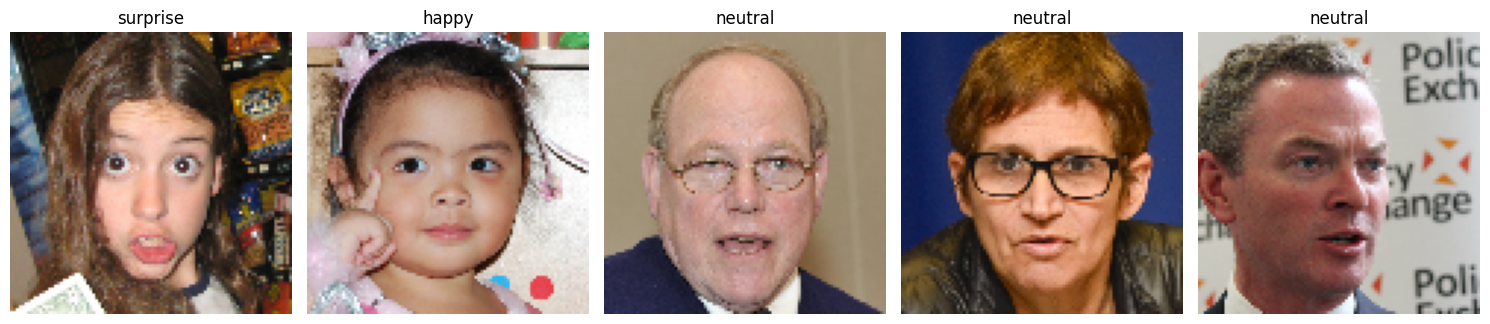

In [10]:
import random
random_indices = random.sample(range(0, len(df)), 5)

plt.figure(figsize=(15, 5))
for i, j in enumerate(random_indices):
    img = cv2.imread(df['file_path'][j])

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img_rgb)
    plt.title(df['emotion_label'][j])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Preprocess data and load model

In [11]:
# 2. Define a fast preprocessing function
# The model expects input shape: (48, 48, 1) and values normalized between 0-1
def preprocess_for_emotion(img_path):

      # Load image in grayscale (0 flag)
      img = cv2.imread(img_path)


      return img
# def preprocess_for_emotion(img_path):
#     img = cv2.imread(img_path)
#     if img is None:
#         # Handle cases where image can't be read (e.g., corrupted file)
#         print(f"Warning: Could not read image {img_path}. Skipping.")
#         return None

#     # Convert to grayscale
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#     # Resize to 48x48
#     img = cv2.resize(img, (48, 48))

#     # Add channel dimension for single channel image (H, W) -> (H, W, 1)
#     img = np.expand_dims(img, axis=-1)

#     # Normalize to 0-1 and convert to float32
#     img = img / 255.0
#     img = img.astype(np.float32)

#     return img

# 3. Prepare the Data
# Assuming df contains your 'file_paths'
print("Preprocessing images...")

# Apply preprocessing to all images
image_data = df['file_path'].apply(preprocess_for_emotion)

image_data = np.array(image_data.tolist())
print("image data shape: ", image_data.shape)

Preprocessing images...
image data shape:  (13206, 96, 96, 3)


# Using the model


In [12]:
MODEL_NAME = "enet_b2_7"
recognizer = EmotiEffLibRecognizer(engine="torch", model_name=MODEL_NAME)

In [ ]:
import inspect
from pprint import pprint
def vdir(obj):
    return [x for x in dir(obj) if not (x.startswith('__') or x.startswith('_'))]
# signature = inspect.signature(recognizer.predict_emotions)
doc = inspect.getdoc(recognizer.predict_emotions)
#print(signature)
print(doc)
# print(vdir(recognizer))
pprint(recognizer.idx_to_emotion_class)
#vdir(emotion_recognizer)
#print((emotion_recognizer.predict_engagement))


Predict the emotions presented on a given facial image or a list of facial images.

Args:
    face_img (Union[np.ndarray, List[np.ndarray]]):
        A single face image (as a NumPy array) or a list of face images.
    logits (bool, optional):
        If True, returns raw model scores (logits). If False, applies softmax normalization
        to obtain probability distributions. Defaults to True.

Returns:
    Tuple[Union[str, List[str]], np.ndarray]:
        - The predicted emotion label(s) as a list of strings (for single image only with
          one element).
        - The corresponding model output scores (logits or probabilities), as a NumPy array.
{0: 'Anger',
 1: 'Disgust',
 2: 'Fear',
 3: 'Happiness',
 4: 'Neutral',
 5: 'Sadness',
 6: 'Surprise'}


[[2.4408516e-02 2.4811390e-03 4.8609766e-01 3.9044159e-04 8.6195795e-03
  3.0817846e-03 4.7492090e-01]]
['Fear']


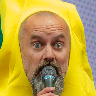

In [13]:
results, logits = recognizer.predict_emotions(image_data[0], logits=False)
# print(f'correct label: {df['emotion_label'][0]}\npredicted labe: {results[0]['dominant_emotion']}\n')
print(logits)
print(results)
cv2_imshow(image_data[0])

In [ ]:
sum = 0
for i in range(len(logits.tolist()[0])):
  sum = sum+ logits[0][i]
  print(logits[0][i])
print(sum)

0.1615325
0.017590847
0.0013460406
0.010105858
0.13791642
0.6712064
0.00030200844
1.0000001


In [14]:
#Predict all results
results = []
print(f"Processing {len(df)} images...")

for i in image_data:
    results.append(recognizer.predict_emotions(i, logits=False))

print("Processing complete.")

Processing 13206 images...
Processing complete.


In [ ]:
len(results)

12271

In [ ]:
results[0][1].tolist()

[[0.0008059439714998007,
  0.00014853912580292672,
  0.0014215823030099273,
  7.615195499965921e-05,
  0.005613489542156458,
  0.9919054508209229,
  2.8801085136365145e-05]]

In [15]:
#this cell saves the output of the model to your drive, incase you want to load it later
def convert_numpy_floats(obj):
    """
    Recursively converts numpy float32 objects to standard Python floats
    within dictionaries and lists.
    """
    if isinstance(obj, dict):
        return {k: convert_numpy_floats(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_floats(elem) for elem in obj]
    elif isinstance(obj, tuple):
        # JSON arrays are equivalent to Python lists, so convert tuple to list
        return [convert_numpy_floats(elem) for elem in obj]
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.float32):
        return float(obj)
    else:
        return obj

# Define the output file path
output_dir = '/content/drive/MyDrive/drive_bys/'
output_filename = 'emotiefflib_affectnet_test_results.json'
output_filepath = os.path.join(output_dir, output_filename)

# Convert numpy.float32 to standard floats before saving
serializable_results = convert_numpy_floats(results)

# Save the results to a JSON file
with open(output_filepath, 'w') as f:
    json.dump(serializable_results, f, indent=4)

print(f"Results saved to: {output_filepath}")

Results saved to: /content/drive/MyDrive/drive_bys/emotiefflib_affectnet_test_results.json


In [16]:
results = json.load(open(f'/content/drive/MyDrive/drive_bys/{output_filename}'))
len(results)

13206

In [ ]:
a, = results[0][1]
results[0]

[['Sadness'],
 [[0.16153250634670258,
   0.017590846866369247,
   0.001346040633507073,
   0.010105857625603676,
   0.1379164159297943,
   0.6712064146995544,
   0.00030200844048522413]]]

# Top1, Topk

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import top_k_accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

# 1. Define the exact order Emotiefflib uses
emotiefflib_to_rafdb_spelling = {
    'Sadness': 'sad',
    'Fear': 'fear',
    'Disgust': 'disgust',
    'Happiness': 'happy',
    'Anger': 'angry',
    'Surprise': 'surprise',
    'Neutral': 'neutral'
}
emotion_order = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

emotion_to_idx = {
    0: 'Anger',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happiness',
    4: 'Neutral',
    5: 'Sadness',
    6: 'Surprise'

}

# 2. Extract Probabilities
# results is the list of lists returned by DeepFace.analyze

y_pred_proba = []

# Iterate through the results corresponding to your dataframe rows
for emotion, probs in results:

    y_pred_proba.append(probs[0])

# Convert to numpy array
y_pred_proba = np.array(y_pred_proba)

# 3. Prepare Ground Truth
# Map string labels from dataframe to integers (0-6) based on emotion_order
le = LabelEncoder()
le.fit(emotion_order) # Force the encoder to use our specific order
y_true = le.transform(df['emotion_label']) # Transform your DF labels

# Get hard predictions (Top-1 class index)
y_pred = np.argmax(y_pred_proba, axis=1)

print(f"Probability Matrix Shape: {y_pred_proba.shape}")

Probability Matrix Shape: (13206, 7)


In [18]:
# --- 1. Top-1 Accuracy ---
top1_acc = top_k_accuracy_score(y_true, y_pred_proba, k=1)

# --- 2. Top-3 Accuracy ---
top3_acc = top_k_accuracy_score(y_true, y_pred_proba, k=3)

# --- 3. F1 Score ---
# "Macro" gives equal weight to all classes (good for checking performance on rare emotions like disgust)
# "Weighted" accounts for class imbalance
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

# Per-class F1 breakdown
report = classification_report(y_true, y_pred, target_names=emotion_order)

print(f"Top-1 Accuracy: {top1_acc:.4f}")
print(f"Top-3 Accuracy: {top3_acc:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print("-" * 30)
print("Per-Class Report:\n", report)

Top-1 Accuracy: 0.6714
Top-3 Accuracy: 0.9347
F1 Score (Macro): 0.6599
------------------------------
Per-Class Report:
               precision    recall  f1-score   support

       angry       0.61      0.64      0.62      1718
     disgust       0.66      0.63      0.64      1248
        fear       0.58      0.71      0.64      1664
       happy       0.91      0.83      0.87      2704
     neutral       0.62      0.61      0.61      2368
         sad       0.61      0.64      0.62      1584
    surprise       0.65      0.59      0.62      1920

    accuracy                           0.67     13206
   macro avg       0.66      0.66      0.66     13206
weighted avg       0.68      0.67      0.67     13206



In [19]:
def compute_ece(y_true, y_pred_proba, n_bins=10):
    """
    Computes Expected Calibration Error (ECE) for multi-class classification.

    Args:
        y_true (array): True integer labels (N,)
        y_pred_proba (array): Predicted probabilities (N, C)
        n_bins (int): Number of bins for calibration
    """
    # 1. Get the max probability (confidence) and the predicted class for each sample
    confidences = np.max(y_pred_proba, axis=1)
    predictions = np.argmax(y_pred_proba, axis=1)

    # 2. Check correctness
    accuracies = (predictions == y_true)

    # 3. Define bin boundaries (0.0 to 1.0)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)

    ece = 0.0
    total_samples = len(y_true)

    for i in range(n_bins):
        # Find samples that fall into this confidence bin
        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        # Mask for samples in this bin
        in_bin = (confidences > lower) & (confidences <= upper)
        prop_in_bin = np.mean(in_bin) # Proportion of samples in this bin

        if prop_in_bin > 0:
            # Accuracy in this bin: mean(correctness)
            accuracy_in_bin = np.mean(accuracies[in_bin])

            # Confidence in this bin: mean(confidence)
            confidence_in_bin = np.mean(confidences[in_bin])

            # Absolute difference * weight
            ece += np.abs(accuracy_in_bin - confidence_in_bin) * prop_in_bin

    return ece

# Calculate ECE
ece_score = compute_ece(y_true, y_pred_proba, n_bins=15)
print(f"Expected Calibration Error (ECE): {ece_score:.4f}")

Expected Calibration Error (ECE): 0.0132


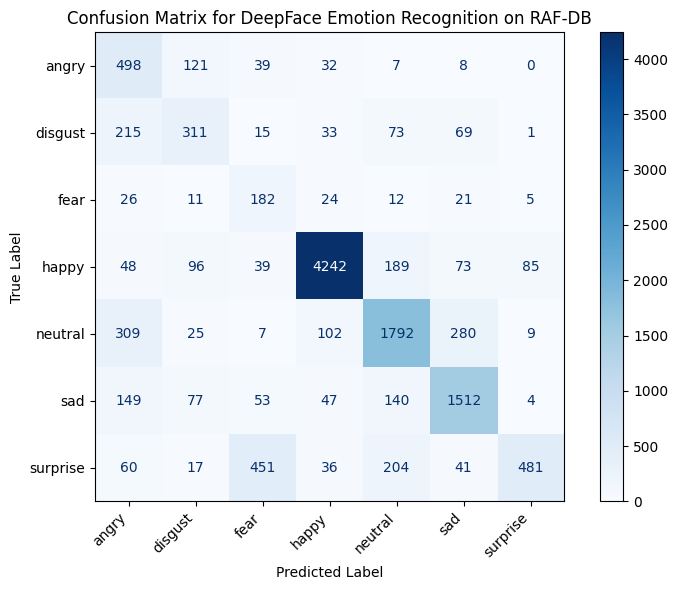

In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Get display labels (emotion_order is already defined in the notebook)
display_labels = emotion_order

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix for DeepFace Emotion Recognition on RAF-DB')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

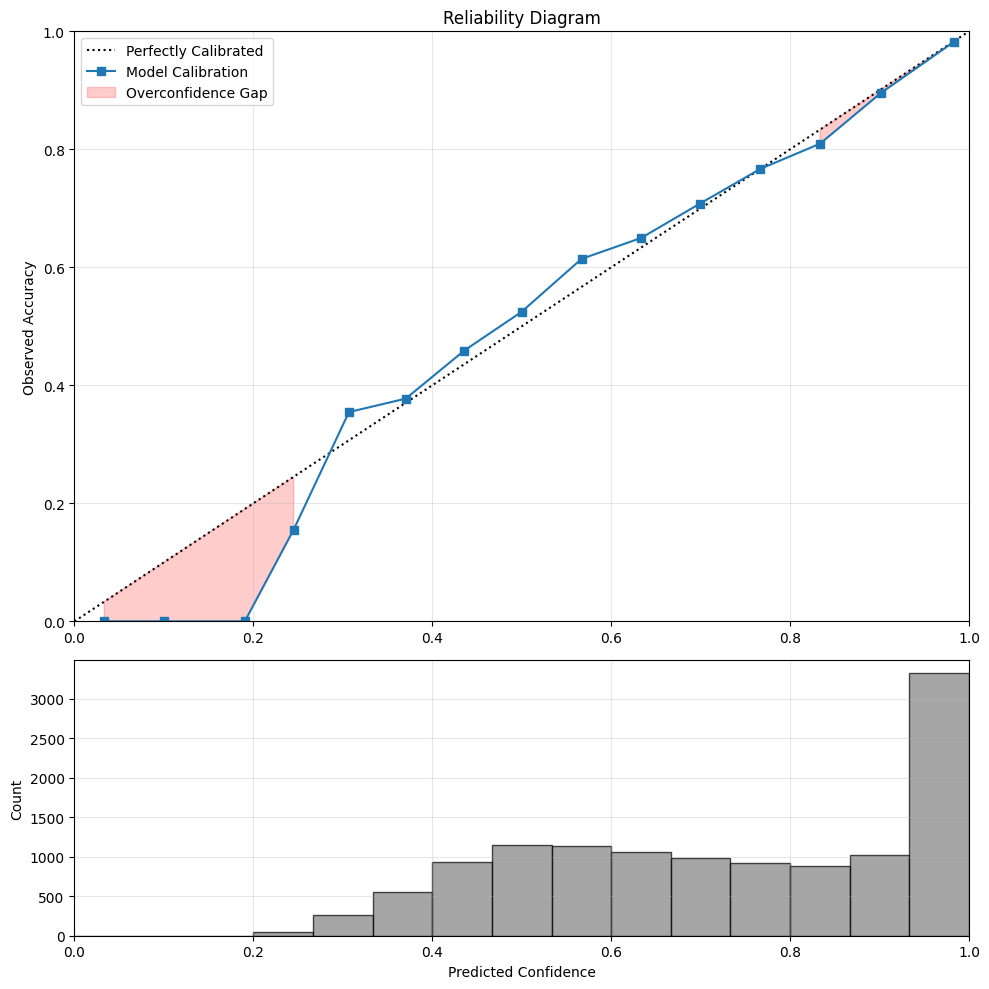

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_reliability_diagram(y_true, y_prob, n_bins=15, title="Reliability Diagram"):
    """
    Plots a multiclass reliability diagram.

    Args:
        y_true: Array of true class indices (0..N).
        y_prob: Array of predicted probabilities (N_samples, N_classes).
        n_bins: Number of bins for the calibration curve.
    """
    # 1. Get the Confidence (max prob) and Prediction for each sample
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)

    # 2. Determine if prediction was correct
    accuracies = (predictions == y_true)

    # 3. Create Bins
    bin_boundaries = np.linspace(0, 1, n_bins + 1)

    bin_accuracies = []
    bin_confidences = []
    bin_counts = []

    for i in range(n_bins):
        # Define bin range
        lower, upper = bin_boundaries[i], bin_boundaries[i+1]

        # Find samples in this bin
        in_bin = (confidences > lower) & (confidences <= upper)
        count = np.sum(in_bin)
        bin_counts.append(count)

        if count > 0:
            # Calculate average accuracy and confidence for this bin
            bin_accuracies.append(np.mean(accuracies[in_bin]))
            bin_confidences.append(np.mean(confidences[in_bin]))
        else:
            bin_accuracies.append(0)
            bin_confidences.append((lower + upper) / 2)

    # --- PLOTTING ---
    plt.figure(figsize=(10, 10))

    # Subplot 1: The Reliability Curve
    ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)

    # Perfect calibration line (Diagonal)
    ax1.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")

    # The Model's curve
    ax1.plot(bin_confidences, bin_accuracies, "s-", label="Model Calibration")

    # Fill areas to highlight over/under confidence
    ax1.fill_between(bin_confidences, bin_confidences, bin_accuracies,
                     where=np.array(bin_accuracies) < np.array(bin_confidences),
                     color='red', alpha=0.2, label="Overconfidence Gap")

    ax1.set_ylabel("Observed Accuracy")
    ax1.set_ylim([0, 1])
    ax1.set_xlim([0, 1])
    ax1.set_title(title)
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # Subplot 2: Confidence Histogram (How many samples in each bin?)
    ax2 = plt.subplot2grid((3, 1), (2, 0))
    ax2.hist(confidences, bins=bin_boundaries, alpha=0.7, color='gray', edgecolor='black')
    ax2.set_xlabel("Predicted Confidence")
    ax2.set_ylabel("Count")
    ax2.set_xlim([0, 1])
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- USAGE ---
# y_true_indices: your integer ground truth (from previous step)
# y_pred_proba: your probability matrix (from previous step)

plot_reliability_diagram(y_true, y_pred_proba, n_bins=15)